<a href="https://colab.research.google.com/github/oaldak01/JupyterNotebook/blob/main/Machine_Learning_ToDo_List.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




# **Simple Linear Regression example: (y = a + bx)**




In [ ]:
import sklearn as sk

In [ ]:
x1, x2 = 3, 4
y1, y2 = 2,4

b = (y2-y1) / (x2 - x1)
a = y1 - (b*x1)

x = -3.5 # random number for demo
y = a + (b*x)
print("a:{}, b:{}, y:{}".format(a,b,y))

a:-4.0, b:2.0, y:-11.0


# **Linear Regression Continuous Algorithm**

In [ ]:
x1, x2, x3 = 3, 4, 7
y1, y2, y3 = 2, 4, 7

b = (y2-y1) / (x2 - x1)
a = y1 - (b * x1)

y3_pred = a + (b * x3)
residual = y3 - y3_pred
a += residual / 3

x = 6
y = a + (b * x)
print("a:{}, b:{}, y:{}".format(a,b,y))

a:-5.0, b:2.0, y:7.0


# **Building a *Decision* Tree Classifier**

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Decision Tree Data/500hits.csv', encoding='latin-1')

In [ ]:
df.head()

,PLAYER,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,CS,BA,HOF
0,Ty Cobb,24,3035,11434,2246,4189,724,295,117,726,1249,357,892,178,0.366,1
1,Stan Musial,22,3026,10972,1949,3630,725,177,475,1951,1599,696,78,31,0.331,1
2,Tris Speaker,22,2789,10195,1882,3514,792,222,117,724,1381,220,432,129,0.345,1
3,Derek Jeter,20,2747,11195,1923,3465,544,66,260,1311,1082,1840,358,97,0.310,1
4,Honus Wagner,21,2792,10430,1736,3430,640,252,101,0,963,327,722,15,0.329,1


In [ ]:
df = df.drop(columns=['PLAYER', 'CS'])

In [ ]:
X = df.iloc[:, 0:13]

In [ ]:
y = df.iloc[:, 13]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 17, test_size = 0.2)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dtc = DecisionTreeClassifier()

In [ ]:
dtc.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [ ]:
dtc.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = dtc.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

In [ ]:
print(cm)

[[52  9]
 [12 20]]


In [ ]:
from sklearn.metrics import classification_report

In [ ]:
cr = classification_report(y_test, y_pred)

In [ ]:
print(cr)

              precision    recall  f1-score   support

           0       0.81      0.85      0.83        61
           1       0.69      0.62      0.66        32

    accuracy                           0.77        93
   macro avg       0.75      0.74      0.74        93
weighted avg       0.77      0.77      0.77        93



In [ ]:
dtc.feature_importances_

array([0.04261692, 0.0154869 , 0.02665246, 0.05287514, 0.38738161,
       0.04325963, 0.04400595, 0.00297051, 0.07925991, 0.08475032,
       0.05241719, 0.07193892, 0.09638455])

In [ ]:
# feature importance is confusing to read so make it into a datafram

In [ ]:
X.columns

Index(['YRS', 'G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'BB', 'SO', 'SB',
       'BA'],
      dtype='object')

In [ ]:
len(X.columns)

13

In [ ]:
#label features with their importance
features = pd.DataFrame(dtc.feature_importances_, index=X.columns)

In [ ]:
features.head(13)

,0
YRS,0.042617
G,0.015487
AB,0.026652
R,0.052875
H,0.387382
2B,0.043260
3B,0.044006
HR,0.002971
RBI,0.079260
BB,0.084750


In [ ]:
# make a new dtc to harness params crit and ccp.
# ccp is for overfitting but sensitve so keep close to zero
dtc2 = DecisionTreeClassifier(criterion='entropy', ccp_alpha=0.04)

In [ ]:
 dtc2.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.04, criterion='entropy')

In [ ]:
y_pred2 = dtc2.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_pred2))

[[50 11]
 [ 9 23]]


In [ ]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.85      0.82      0.83        61
           1       0.68      0.72      0.70        32

    accuracy                           0.78        93
   macro avg       0.76      0.77      0.77        93
weighted avg       0.79      0.78      0.79        93



In [ ]:
features2 = pd.DataFrame(dtc2.feature_importances_, index=X.columns)

# **CCP kept batting averages and hits and removed all other insignifact potentially overfit data!**

In [ ]:
features2.head(13)

,0
YRS,0.000000
G,0.000000
AB,0.000000
R,0.000000
H,0.837977
2B,0.000000
3B,0.000000
HR,0.000000
RBI,0.000000
BB,0.000000


# **Building a Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier()

In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
ypredRF = rf.predict(X_test)

In [ ]:
# rf score returns mean accuracy of correctly classified (simiar to confusion matrix, evaluates model performance)
rf.score(X_test, y_test)

0.8172043010752689

In [ ]:
cr = classification_report(y_test, ypredRF)
print(cr)

              precision    recall  f1-score   support

           0       0.83      0.90      0.87        61
           1       0.78      0.66      0.71        32

    accuracy                           0.82        93
   macro avg       0.81      0.78      0.79        93
weighted avg       0.81      0.82      0.81        93



In [ ]:
features = pd.DataFrame(rf.feature_importances_, index=X.columns)

In [ ]:
features.head(13)

,0
YRS,0.025025
G,0.078677
AB,0.091527
R,0.127650
H,0.148485
2B,0.066258
3B,0.042773
HR,0.056701
RBI,0.088764
BB,0.043903


# ***Hyper Parameters***

In [ ]:
# the following is RandomClassifier hyperparameters typically used
rf2 = RandomForestClassifier(
  n_estimators=1000,
  criterion='entropy',
  min_samples_split=10,
  max_depth = 14,
  random_state=42
)

In [ ]:
rf2.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=14, min_samples_split=10,
                       n_estimators=1000, random_state=42)

In [ ]:
rf2.score(X_test, y_test)

0.8494623655913979

In [ ]:
ypredRF2 = rf2.predict(X_test)

In [ ]:
print(classification_report(y_test, ypredRF2))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        61
           1       0.85      0.69      0.76        32

    accuracy                           0.85        93
   macro avg       0.85      0.81      0.82        93
weighted avg       0.85      0.85      0.85        93



# ***HyperParameter Tuning***

####**hyperparameter-tuning allows you to chose multiple values/iterations to test best accuracy**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
mean1 = 55
std_dev1 = 10
num_samples = 500

column1_numbers = np.random.normal(mean1, std_dev1, num_samples)
column1_numbers = np.clip(column1_numbers, 30, 120)
column1_numbers = np.round(column1_numbers).astype(int)

mean2 = 18
std_dev2 = 3

column2_numbers = np.random.normal(mean2, std_dev2, num_samples)
column2_numbers = np.clip(column2_numbers, 12, 26)
column2_numbers = np.round(column2_numbers).astype(int)

column3_numbers = np.random.randint(2, size=num_samples)
column3_numbers[column1_numbers > mean1] = 1

data = {'Miles_Per_week': column1_numbers,
        'Farthest_run': column2_numbers,
        'Qualified_Boston_Marathon': column3_numbers}

df = pd.DataFrame(data)

In [ ]:
df = pd.DataFrame(data)

In [ ]:
df.head(10)

,Miles_Per_week,Farthest_run,Qualified_Boston_Marathon
0,65,16,1
1,68,20,1
2,50,20,0
3,48,21,1
4,41,17,0
5,70,17,1
6,59,12,1
7,54,20,1
8,56,18,1
9,43,22,0


In [ ]:
X = df.iloc[:, 0:2]

In [ ]:
y = df.iloc[:, 2]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 26, test_size = 0.3)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier()

In [ ]:
# param_grid: dictionary used for hyperparameter tuning
random_param_grid = [{
    'n_estimators': [500, 1000, 1500],
    'criterion': ['entropy'],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [1,2,4],
    'max_depth': [10,20,30]
    }]

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv =2,
    scoring = 'accuracy',
    n_jobs = -1
)

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=2, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid=[{'min_samples_leaf': [1, 2, 4],
                          'min_samples_split': [5, 10, 15],
                          'n_estimators': [500, 1000, 1500]}],
             scoring='accuracy')

In [ ]:
grid_search.best_score_

np.float64(0.7028571428571428)

In [ ]:
grid_search.best_params_

{'min_samples_leaf': 2, 'min_samples_split': 15, 'n_estimators': 1500}

In [ ]:
# randomized

from sklearn.model_selection import RandomizedSearchCV

In [ ]:
random_grid_search = RandomizedSearchCV(
    rf,
    random_param_grid,
    cv=5,
    scoring = 'accuracy',
    n_jobs = -1,
    random_state = 26
)

In [ ]:
random_grid_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions=[{'criterion': ['entropy'],
                                         'max_depth': [10, 20, 30],
                                         'min_samples_leaf': [1, 2, 4],
                                         'min_samples_split': [5, 10, 15],
                                         'n_estimators': [500, 1000, 1500]}],
                   random_state=26, scoring='accuracy')

In [ ]:
random_grid_search.best_score_

np.float64(0.7342857142857143)

In [ ]:
random_grid_search.best_params_

{'n_estimators': 500,
 'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_depth': 20,
 'criterion': 'entropy'}

# **------------------------------------------------**

# ***Gradient Descent***

In [ ]:
import numpy as np

# Activation Function
def sigmoid(w_sum):
  return 1/(1+np.exp(-w_sum))

# Get Prediction
def predict(features, weights, bias):
    return sigmoid(np.dot(features, weights) + bias)

# loss function
def cross_entropy(target, pred):
  return -(target*np.log10(pred)+(1-target)*(np.log10(1-pred)))

# update weights
def gradient_descent(feature, weights, target, prediction, l_rate, bias):

  new_weights = []
  bias += l_rate*(target-prediction)

  for x,w in zip(feature, weights):
    new_w = w + l_rate*(target-prediction)*x
    new_weights.append(new_w)

  return new_weights, bias

# Data
features = np.array((

    [0.1,0.5,0.2],
    [0.2,0.3,0.1],
    [0.7,0.4,0.2],
    [0.1,0.4,0.3]))

targets = np.array([0,1,0,1])

epochs = 10
learnrate = 0.1

errors = []
weights = np.array([0.4, 0.2, 0.6])
bias = 0.5

new_weights = []

for e in range(epochs):
    for x, y in zip(features, targets):
        pred = predict(x, weights, bias)
        error = cross_entropy(y, pred)
        weights, bias = gradient_descent(x, weights, y, pred, learnrate, bias)

    # Printing out the log-loss error on the training set
    out = predict(features, weights, bias)
    loss = np.mean(cross_entropy(targets, out))
    errors.append(loss)
    print("\n========== Epoch", e,"==========")
    print("Average loss: ", loss)


========== Epoch 0 ==========
Average loss:  0.33944294852408824

========== Epoch 1 ==========
Average loss:  0.33147083470744965

========== Epoch 2 ==========
Average loss:  0.32499752814643046

========== Epoch 3 ==========
Average loss:  0.31973828925825093

========== Epoch 4 ==========
Average loss:  0.3154527992144233

========== Epoch 5 ==========
Average loss:  0.3119424130828664

========== Epoch 6 ==========
Average loss:  0.30904555254773175

========== Epoch 7 ==========
Average loss:  0.3066324010104734

========== Epoch 8 ==========
Average loss:  0.30459963557320424

========== Epoch 9 ==========
Average loss:  0.30286560086854775


# **------------------------------------------------**

# ***K-NEAREST NEIGHBOR***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/breastCancerKNN_Data.csv')
X = data.drop(columns=['id','diagnosis']).values
y = data['diagnosis'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

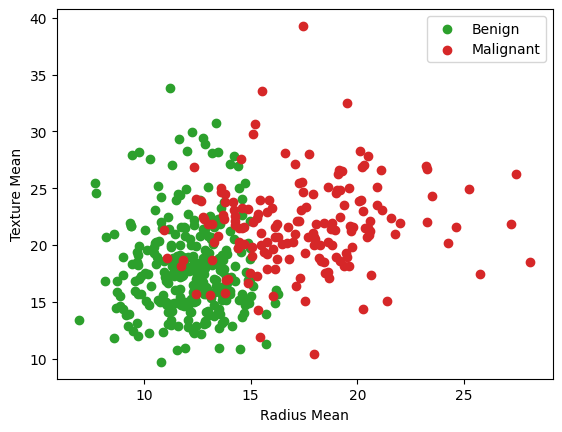

In [ ]:
plt.scatter(X_train[y_train == 'B', 0], X_train[y_train == 'B', 1],color='tab:green', label='Benign')
plt.scatter(X_train[y_train == 'M', 0],X_train[y_train == 'M', 1], color='tab:red', label='Malignant')
plt.xlabel('Radius Mean')
plt.ylabel('Texture Mean')
plt.legend()
plt.show()

In [ ]:
def euclidean_distance(a,b):
  return np.sqrt(np.sum((b-a) ** 2))

In [ ]:
class KNN:
  def __init__(self, k):
      self.k = k

  def fit(self, X, y):
      self.X_train = X
      self.y_train = y

  def predict(self, new_points):
      predictions = [self.predict_class(new_point) for new_point in new_points]
      return np.array(predictions)

  def predict_class(self, new_point):
      distances = [euclidean_distance(point, new_point) for point in self.X_train]

      k_nearest_indices = np.argsort(distances)[:self.k]
      k_nearest_labels = [self.y_train[i] for i in k_nearest_indices]

      most_common = Counter(k_nearest_labels).most_common(1)[0][0]

      return most_common

In [ ]:
knn = KNN(7)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
accuracy = np.mean(predictions == y_test) * 100
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 60.53%


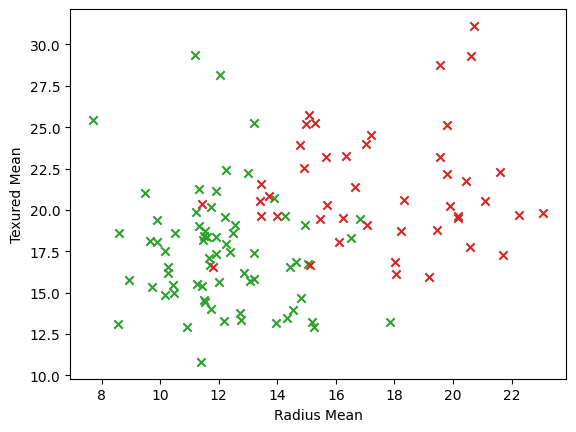

In [ ]:
plt.scatter(X_test[y_test == 'B', 0], X_test[y_test == 'B', 1], color='tab:green', label='Predicted Benign', marker='x')
plt.scatter(X_test[y_test == 'M', 0], X_test[y_test == 'M', 1], color='tab:red', label='Predicted Malignant', marker='x')
plt.xlabel("Radius Mean")
plt.ylabel("Texured Mean")
plt.show()

# **------------------------------------------------**

# ***SVM: SUPPORT VECTOR MACHINE***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets


In [ ]:

X, y = datasets.make_blobs(
    n_samples=50, n_features=2, centers=2, cluster_std=1.05, random_state=40
)

y = np.where(y == 0, -1, 1)

clf = SVM()
clf.fit(X, y)



In [ ]:
class SVM:
  def __init__(self, learning_rate=0.001, lambda_param=0.001, n_iters=1000):
      self.lr = learning_rate
      self.lambda_param = lambda_param
      self.n_iters = n_iters
      self.w = None
      self.b = None

  def fit(self, X, y):
      y_ = np.where(y <= 0, -1, 1)
      n_samples, n_features = X.shape

      self.w = np.zeros(n_features)
      self.b = 0

      for _ in range(self.n_iters):
          for idx, x_i in enumerate(X):
              condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
              if condition:
                  self.w -= self.lr * (2 * self.lambda_param * self.w)
              else:
                  self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                  self.b -= self.lr * y_[idx]

  def predict(self, X):
      linear_output = np.dot(X, self.w) - self.b
      return np.sign(linear_output)



[0.60495733 0.16911775] -0.06800000000000005


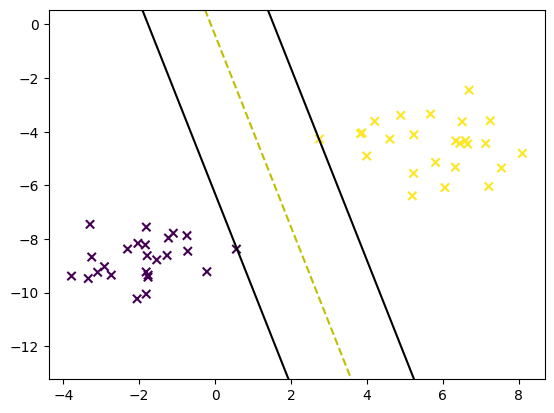

In [ ]:
# Testing
if __name__ == "__main__":
    # Imports
    from sklearn import datasets
    import matplotlib.pyplot as plt

    X, y = datasets.make_blobs(
        n_samples=50, n_features=2, centers=2, cluster_std=1.05, random_state=40
    )
    y = np.where(y == 0, -1, 1)

    clf = SVM()
    clf.fit(X, y)

    # predictions = clf.predict(X)
    print(clf.w, clf.b)

    def visualize_svm():
        def get_hyperplane_value(x, w, b, offset):
            return (-w[0] * x + b + offset) / w[1]

        fig = plt.figure()
        ax = fig.add_subplot(1, 1, 1)

        plt.scatter(X[:, 0], X[:, 1], marker="x", c=y)

        x0_1 = np.amin(X[:, 0])
        x0_2 = np.amax(X[:, 0])

        x1_1 = get_hyperplane_value(x0_1, clf.w, clf.b, 0)
        x1_2 = get_hyperplane_value(x0_2, clf.w, clf.b, 0)

        x1_1_m = get_hyperplane_value(x0_1, clf.w, clf.b, -1)
        x1_2_m = get_hyperplane_value(x0_2, clf.w, clf.b, -1)

        x1_1_p = get_hyperplane_value(x0_1, clf.w, clf.b, 1)
        x1_2_p = get_hyperplane_value(x0_2, clf.w, clf.b, 1)

        ax.plot([x0_1, x0_2], [x1_1, x1_2], "y--")
        ax.plot([x0_1, x0_2], [x1_1_m, x1_2_m], "k")
        ax.plot([x0_1, x0_2], [x1_1_p, x1_2_p], "k")

        x1_min = np.amin(X[:, 1])
        x1_max = np.amax(X[:, 1])
        ax.set_ylim([x1_min - 3, x1_max + 3])

        plt.show()

    visualize_svm()


# ***`SINGULAR VALUE DECOMPOSTION SVD`***

In [ ]:
import numpy as np

In [ ]:
def eigen_solver(square_matrix):
  """Computes eigenvalues and eigenvectors for a square matrix."""
  # np.linalg.eigh is used for symmetric matrices, which is typical in SVD decomposition steps.
  eigenvalues, eigenvectors = np.linalg.eigh(square_matrix)
  return eigenvalues, eigenvectors
  print("The 'eigen_solver' function has been defined.")

In [ ]:
def custom_svd(A):
  """Implements Singular Value Decomposition (SVD) from scratch."""
  # Calculate covariance matrices
  A_transpose_A = A.T @ A
  A_A_transpose = A @ A.T

  # Get teigenvalues and eigenvectors using the eigen_solver
  eigenvalues_AtA, eigenvectors_AtA = eigen_solver(A_transpose_A)
  eigenvalues_AAt, eigenvectors_AAt = eigen_solver(A_A_transpose)

  # Sort eigenvalues and eigenvectors in descending order for A_transpose_A
  idx_AtA = eigenvalues_AtA.argsort()[::-1]
  eigenvalues_AtA = eigenvalues_AtA[idx_AtA]
  eigenvectors_AtA = eigenvectors_AtA[:, idx_AtA]

  # Sort eigenvalues and eigenvectors in descending order for A_A_transpose
  idx_AAt = eigenvalues_AAt.argsort()[::-1]
  eigenvalues_AAt = eigenvalues_AAt[idx_AAt]
  eigenvectors_AAt = eigenvectors_AAt[:, idx_AAt]

  # Extract singular values (Sigma) from non-negative eigenvalues of A_transpose_A
  # Singular values are the square root of eigenvalues
  singular_values = np.sqrt(np.maximum(eigenvalues_AtA, 0))
  # Create Sigma matrix (diagonal matrix with singular values)
  # The size of Sigma should match the original matrix dimensions (min(m, n))
  min_dim = min(A.shape)
  Sigma = np.zeros(A.shape)
  Sigma[:min_dim, :min_dim] = np.diag(singular_values[:min_dim])
  # Construct V_transpose (right singular vectors are eigenvectors of A_transpose_A)
  V_transpose = eigenvectors_AtA.T
  # Construct U (left singular vectors are eigenvectors of A_A_transpose)
  U = eigenvectors_AAt
  # Adjust U and V such that U @ Sigma @ V_transpose closely reconstructs A
  # This step handles potential sign flips due to eigen_solver
  # (A @ V_transpose.T)[:, :min_dim] should be proportional to U[:, :min_dim] @ Sigma[:min_dim, :min_dim]
  # A common way to align them is to check the first column
  for i in range(min_dim):
  col_A_times_v = (A @ eigenvectors_AtA[:, i])
  col_u_times_sigma = U[:, i] * singular_values[i]
  if not np.isclose(np.linalg.norm(col_A_times_v), np.linalg.norm(col_u_times_sigma), atol=1e-5):
  if np.linalg.norm(col_A_times_v) > 1e-5: # Avoid division by zero
  # If magnitudes are different, it implies a sign mismatch or scaling issue
  # For simple sign flips, we can check a dot product for alignment
  if np.dot(col_A_times_v, col_u_times_sigma) < 0:
  U[:, i] *= -1
  return U, Sigma, V_transpose
  print("The 'custom_svd' function has been defined.")

## Summary:

### Data Analysis Key Findings

*   The `numpy` library was successfully imported for numerical operations.
*   A helper function, `eigen_solver`, was successfully defined to calculate eigenvalues and eigenvectors for a square matrix using `np.linalg.eigh`. This function is crucial for the subsequent SVD computation.
*   The `custom_svd` function was successfully implemented, providing a scratch-built Singular Value Decomposition algorithm. This implementation involves:
    *   Calculating the covariance matrices, $\text{A}^T\text{A}$ and $\text{AA}^T$.
    *   Utilizing the `eigen_solver` to obtain eigenvalues and eigenvectors for these covariance matrices.
    *   Sorting the eigenvalues and their corresponding eigenvectors in descending order.
    *   Extracting singular values as the square root of the non-negative eigenvalues from $\text{A}^T\text{A}$.
    *   Constructing the $\Sigma$ matrix as a diagonal matrix using these singular values.
    *   Deriving the $\text{V}^T$ matrix (right singular vectors) from the eigenvectors of $\text{A}^T\text{A}$.
    *   Deriving the U matrix (left singular vectors) from the eigenvectors of $\text{AA}^T$.
    *   Including a sign adjustment step for U to ensure consistency in the decomposition.

### Insights or Next Steps

*   The core components for performing SVD from scratch (library import, eigen-solver, and the SVD algorithm itself) have been successfully implemented and defined.
*   The immediate next step is to test the `custom_svd` implementation with a sample matrix and compare its results (U, $\Sigma$, $\text{V}^T$) against NumPy's built-in SVD function to validate its correctness and accuracy.
